In [1]:
import numpy as np
import matplotlib.pyplot as plt
import PIL

In [2]:
path = '/scratch/radjoe/Projects/Experiments/SAMEXP/results_TTA/BraTS_SSA/MedSAM2/boxes/BraTS-SSA-00002-000.npy'

In [3]:
img = np.load(path)

In [4]:
img.shape

(3, 192, 224, 160)

In [5]:
np.unique(img[1,:,:,80])

array([0., 1.])

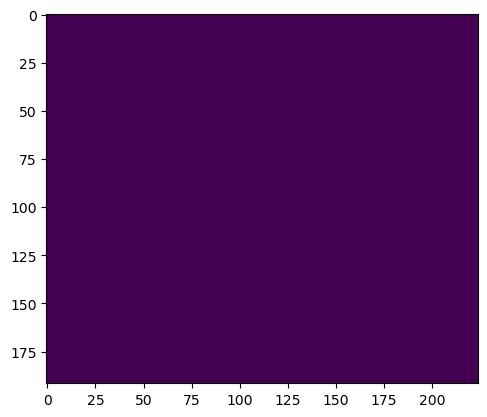

In [8]:
plt.imshow(img[2,:,:,80])

In [98]:
import random
import torch
from PIL import Image

def mask_to_points(mask):
      mask = (mask == 255).to(torch.uint8)
      ys, xs = np.where(mask == 1)
      num_points = len(xs)
      yn , xn = np.where(mask == 0)
      n_points = len(xn)

      indices_n = random.sample(range(n_points), 5)

      unsampled_points = [(xn[i], yn[i]) for i in indices_n]

      if num_points == 0:
            sampled_points = [(-1, -1)] * 5  # No points at all
      elif num_points < 5:
            indices = random.sample(range(num_points), num_points)
            sampled_points = [(xs[i], ys[i]) for i in indices]
            # Pad with -1s
            sampled_points += [(-1, -1)] * (5 - len(sampled_points))
      else:
            indices = random.sample(range(num_points), 5)
            sampled_points = [(xs[i], ys[i]) for i in indices]

      results = sampled_points + unsampled_points
      
      return results


In [99]:
label = Image.open('/scratch_net/ken/radjoe/training/1st_manual/21_manual1.gif')
label_np = np.array(label)
label = torch.tensor(label_np)  

In [100]:

points = mask_to_points(label)
xs, ys = zip(*points)

In [101]:
points

[(473, 419),
 (194, 75),
 (192, 123),
 (273, 506),
 (269, 227),
 (426, 533),
 (383, 286),
 (87, 515),
 (370, 246),
 (234, 457)]

In [102]:
np.unique(label)

array([  0, 255], dtype=uint8)

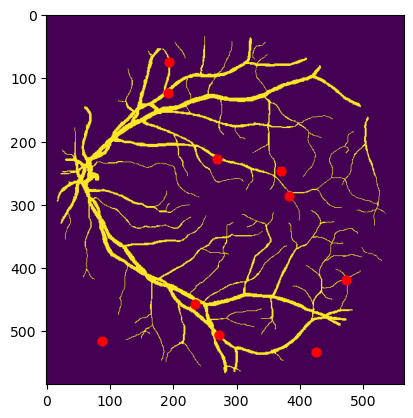

In [104]:
plt.imshow(label)
plt.scatter(xs, ys, c='red', s=40, label='Sampled Points')

In [183]:
points = mask_to_points(label)

In [184]:
points

[(445, 327),
 (312, 547),
 (497, 560),
 (406, 203),
 (314, 405),
 (496, 593),
 (42, 233),
 (610, 141),
 (290, 243),
 (108, 75)]